# Expected cross section uncertainties from SHiP and SND@HL-LHC measurements in RUN 4

## First, open the SHiP and SND@LHC simulations separately to scale the energies to the expected number of CCDIS events and sum them together

In [1]:
import ROOT as r

In [2]:
%jsroot off

## SHiP simulation file

Retrieve the dataframe

Plot the neutrino energy for CCDIS interactions, 

scale it to the expected number of CCDIS events for one year (**SPSC-P-369**)

In [3]:
prepath = "/eos/user/a/aiuliano/public/sims_FairShip/GenieEvents_SHIP/GenieEvents_2026_03/2026_03_16_1year_allflavours/"
gstfileship = r.TFile.Open(prepath+"nu_1year_fluxhanae34.gst.root")
rootrackerfileship = r.TFile.Open(prepath+"nu_1year_fluxhanae34.rootracker.root")

gstship = gstfileship.Get("gst")
rootrackership = rootrackerfileship.Get("gRooTracker")

gstship.AddFriend(rootrackership)
dfship = r.RDataFrame(gstship)

In [4]:
import numpy as np
from array import array
# logaritmic binning parameters
# We want 10 bins per decade, and we want the bins to appear equally spaced on a logarithmic scale
nbinsE = 40
E_min = 1.     
E_max = 10000.

# Generate borders of logarithms bins
Ebin_borders = np.logspace(np.log10(E_min), np.log10(E_max), nbinsE + 1)

In [5]:
E_max = 4000.
Ebin_borders = Ebin_borders[Ebin_borders<E_max]
nbinsE = len(Ebin_borders)-1

In [6]:
# Conversion to c++
Ebin_borders_c = array('d', Ebin_borders)

In [7]:
#filter per neutrino type
dfship_numu = dfship.Filter("neu==14");
#target must be tungsten
dfship_numu_W = dfship_numu.Filter("tgt==1000741840");
hEship_CCDIS_numu = dfship_numu_W.Filter("cc&&dis").Histo1D(("hEship_CCDIS_numu","Energy CCDIS nu mu",nbinsE,Ebin_borders_c),"Ev")

In [8]:
#filter per neutrino type
dfship_numu_bar = dfship.Filter("neu==-14");
#target must be tungsten
dfship_numu_bar_W = dfship_numu_bar.Filter("tgt==1000741840");
hEship_CCDIS_numu_bar = dfship_numu_bar_W.Filter("cc&&dis").Histo1D(("hEship_CCDIS_numu_bar","Energy CCDIS nu mu bar",nbinsE,Ebin_borders_c),"Ev")

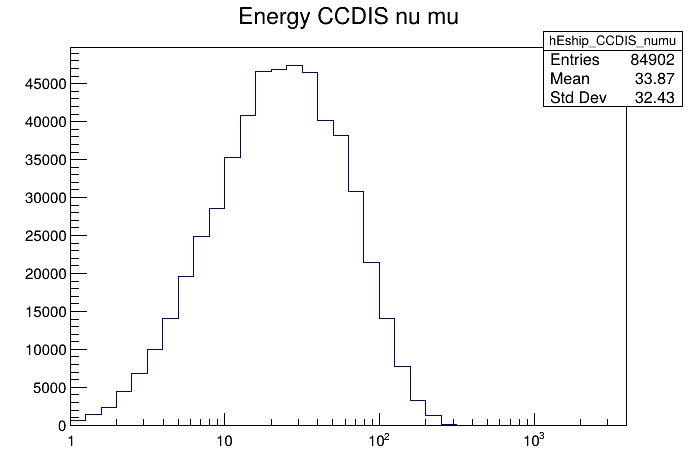

In [9]:
n_numu_CCDIS_ship = 8e+6/15. #one year of data taking, end of Run 4
cE_CCDIS_numu = r.TCanvas()
hEship_CCDIS_numu.Scale(n_numu_CCDIS_ship/hEship_CCDIS_numu.Integral())
hEship_CCDIS_numu.Draw("histo")
cE_CCDIS_numu.SetLogx()
cE_CCDIS_numu.Draw()

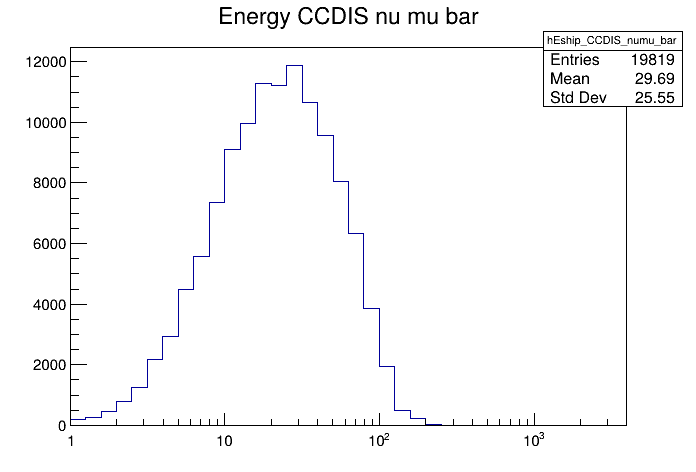

In [10]:
n_numu_bar_CCDIS_ship = 1.8e+6/15. #one year of data taking, end of Run 4
cE_CCDIS_numu_bar = r.TCanvas()
hEship_CCDIS_numu_bar.Scale(n_numu_bar_CCDIS_ship/hEship_CCDIS_numu_bar.Integral())
hEship_CCDIS_numu_bar.Draw("histo")
cE_CCDIS_numu_bar.SetLogx()
cE_CCDIS_numu_bar.Draw()

## SND@HL-LHC

Same as before, we open the other file and we plot the other histogram of energies

The number of expected neutrino interactions is from **LHCC-P-026**

In [11]:
prepath = "/eos/experiment/sndlhc/users/aiulian/Neutrino_MC_merged/sndlhc_13TeV_down_volTarget_100fb-1_SNDG18_02a_01_000/"
gstfilesndlhc = r.TFile.Open(prepath+"sndlhc_+volTarget_all_SNDG18_02a_01_000.0.gst.root")
rootrackerfilesndlhc = r.TFile.Open(prepath+"sndlhc_+volTarget_all_SNDG18_02a_01_000.0.rootracker.root")

gstsndlhc = gstfilesndlhc.Get("gst")
rootrackersndlhc = rootrackerfilesndlhc.Get("gRooTracker")

gstsndlhc.AddFriend(rootrackersndlhc)
dfsndlhc = r.RDataFrame(gstsndlhc)

In [12]:
#filter per neutrino type
dfsndlhc_numu = dfsndlhc.Filter("neu==14");
#target must be tungsten
dfsndlhc_numu_W = dfsndlhc_numu.Filter("tgt==1000741840");
hEsndlhc_CCDIS_numu = dfsndlhc_numu_W.Filter("cc&&dis").Histo1D(("hEsndlhc_CCDIS_numu","Energy CCDIS nu mu",nbinsE,Ebin_borders_c),"Ev")

In [13]:
#filter per neutrino type
dfsndlhc_numu_bar = dfsndlhc.Filter("neu==-14");
#target must be tungsten
dfsndlhc_numu_bar_W = dfsndlhc_numu_bar.Filter("tgt==1000741840");
hEsndlhc_CCDIS_numu_bar = dfsndlhc_numu_bar_W.Filter("cc&&dis").Histo1D(("hEsndlhc_CCDIS_numu_bar","Energy CCDIS nu mu bar",nbinsE,Ebin_borders_c),"Ev")

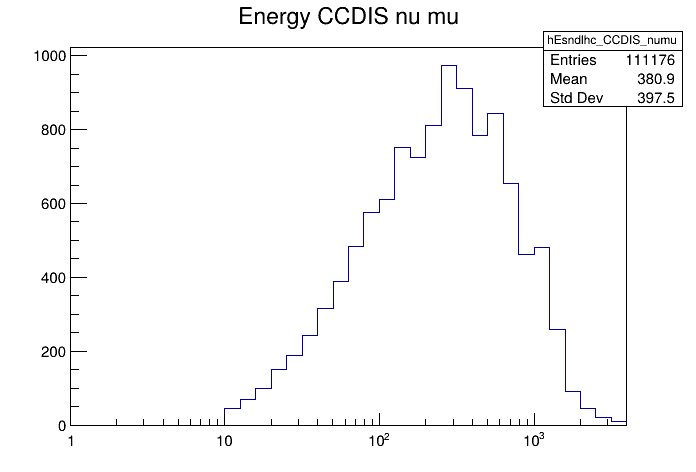

In [14]:
n_numu_CCDIS_sndlhc = 9.6e+3+1.4e+3 
cEsndlhc_CCDIS_numu = r.TCanvas()
hEsndlhc_CCDIS_numu.Scale(n_numu_CCDIS_sndlhc/hEsndlhc_CCDIS_numu.Integral())
hEsndlhc_CCDIS_numu.Draw("histo")
cEsndlhc_CCDIS_numu.SetLogx()
cEsndlhc_CCDIS_numu.Draw()

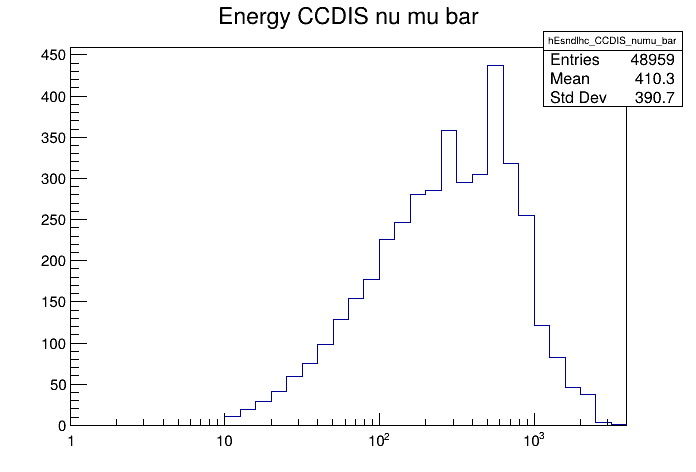

In [15]:
n_numu_bar_CCDIS_sndlhc = 3.1e+3+9.9e+2 
cEsndlhc_CCDIS_numu_bar = r.TCanvas()
hEsndlhc_CCDIS_numu_bar.Scale(n_numu_bar_CCDIS_sndlhc/hEsndlhc_CCDIS_numu_bar.Integral())
hEsndlhc_CCDIS_numu_bar.Draw("histo")
cEsndlhc_CCDIS_numu_bar.SetLogx()
cEsndlhc_CCDIS_numu_bar.Draw()

## SHiP + SNDLHC neutrino energies

Summing together the two histograms

Resetting the bin errors to the sqrt of bin content for energy bin

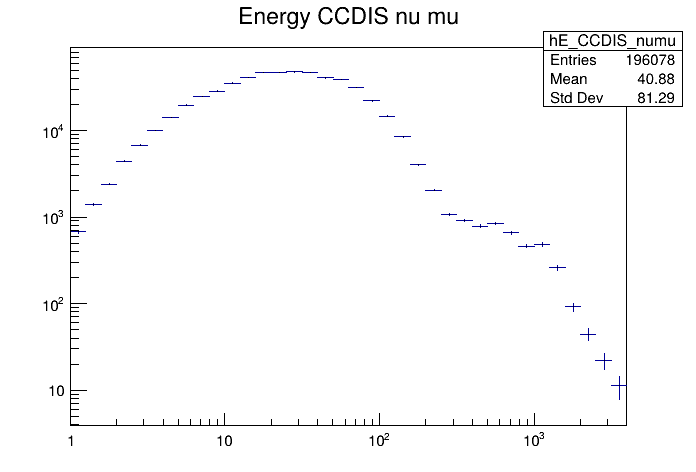

In [16]:
cE_CCDIS_numu = r.TCanvas()
hE_CCDIS_numu = r.TH1D("hE_CCDIS_numu","Energy CCDIS nu mu",nbinsE,Ebin_borders_c)

hE_CCDIS_numu.Add(hEship_CCDIS_numu.GetPtr())
hE_CCDIS_numu.Add(hEsndlhc_CCDIS_numu.GetPtr())


for i in range(1, hE_CCDIS_numu.GetNbinsX() + 1):
    content = hE_CCDIS_numu.GetBinContent(i)
    # Reset error to sqrt(content)
    hE_CCDIS_numu.SetBinError(i, r.TMath.Sqrt(content))

    hE_CCDIS_numu.Draw("E")
cE_CCDIS_numu.SetLogy()
cE_CCDIS_numu.SetLogx()
cE_CCDIS_numu.Draw()

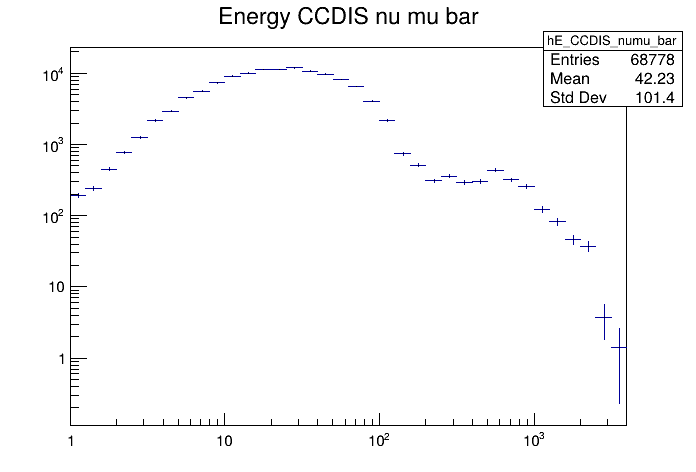

In [17]:
cE_CCDIS_numu_bar = r.TCanvas()
hE_CCDIS_numu_bar = r.TH1D("hE_CCDIS_numu_bar","Energy CCDIS nu mu bar",nbinsE,Ebin_borders_c)

hE_CCDIS_numu_bar.Add(hEship_CCDIS_numu_bar.GetPtr())
hE_CCDIS_numu_bar.Add(hEsndlhc_CCDIS_numu_bar.GetPtr())


for i in range(1, hE_CCDIS_numu_bar.GetNbinsX() + 1):
    content = hE_CCDIS_numu_bar.GetBinContent(i)
    # Reset error to sqrt(content)
    hE_CCDIS_numu_bar.SetBinError(i, r.TMath.Sqrt(content))

    hE_CCDIS_numu_bar.Draw("E")
cE_CCDIS_numu_bar.SetLogy()
cE_CCDIS_numu_bar.SetLogx()
cE_CCDIS_numu_bar.Draw()

# Retrieving the cross section

Now we can move to the cross sections CCDIS

Both for numu and anti-numu, merging the SHiP and SNDLHC

We rescale them to the relative error from the neutrino energy spectra

In [18]:
prepath = "/eos/user/a/aiuliano/public/sims_FairShip/GenieEvents_SHIP/GenieEvents_2026_03/2026_03_16_1year_allflavours/"
chaingst = r.TChain("gst")
chaingst.Add(prepath+"nu_1year_fluxhanae34.gst.root")
chaingst.AddFile("/eos/experiment/sndlhc/users/aiulian/Neutrino_MC_merged/sndlhc_13TeV_down_volTarget_100fb-1_SNDG18_02a_01_000/sndlhc_+volTarget_all_SNDG18_02a_01_000.0.gst.root")

chainrootracker = r.TChain("gRooTracker")
chainrootracker.Add(prepath+"nu_1year_fluxhanae34.rootracker.root")
chainrootracker.AddFile("/eos/experiment/sndlhc/users/aiulian/Neutrino_MC_merged/sndlhc_13TeV_down_volTarget_100fb-1_SNDG18_02a_01_000/sndlhc_+volTarget_all_SNDG18_02a_01_000.0.rootracker.root")
#gstfile = r.TFile.Open(prepath+"nu_1year_fluxhanae34.gst.root")
#rootrackerfile = r.TFile.Open(prepath+"nu_1year_fluxhanae34.rootracker.root")

#gstfile = r.TFile.Open("/eos/experiment/sndlhc/users/aiulian/Neutrino_MC_merged/sndlhc_13TeV_down_volTarget_100fb-1_SNDG18_02a_01_000/sndlhc_+volTarget_all_SNDG18_02a_01_000.0.gst.root")
#rootrackerfile = r.TFile.Open("/eos/experiment/sndlhc/users/aiulian/Neutrino_MC_merged/sndlhc_13TeV_down_volTarget_100fb-1_SNDG18_02a_01_000/sndlhc_+volTarget_all_SNDG18_02a_01_000.0.rootracker.root")

#gsttree = gstfile.Get("gst")
#rootrackertree = rootrackerfile.Get("gRooTracker")

#gsttree.AddFriend(rootrackertree)
chaingst.AddFriend(chainrootracker)

In [19]:
df = r.RDataFrame(chaingst);

In [20]:
df1 = df.Define("log10_E","log10(Ev)")
df2 = df1.Define("xsecN_overE","gRooTracker.EvtXSec/(Ev*184)")

In [21]:
#filter per neutrino type
df_numu = df2.Filter("neu==14");
#target must be tungsten
df_numu_W = df_numu.Filter("tgt==1000741840");

In [22]:
nbinsxsec = 1000;
minxsec = 0.;
maxxsec = 1.;

In [23]:
def selectchannel(cc,inttype,hitnuc,charm,sea = "None",hitqrk = "None", resid = "None"):
 dfint = df_numu_W.Filter(cc+"&&"+inttype+"&&"+hitnuc+"&&"+charm)
 if (inttype=="dis"):
     dfintqrk = dfint.Filter(sea+"&&"+hitqrk)
     return dfintqrk
 if (inttype=="res"):
     dfintqrk = dfint.Filter(resid)
     return dfintqrk
 
 else: 
     return dfint
    

In [24]:
charge = ["cc"]
charms = ["charm","!charm"]
inttypes = ["qel","mec","coh","imd","nuel"]


hitnuclei = ["hitnuc==2212","hitnuc==2112"]

In [25]:
profiles = []
for cc in charge:
    for inttype in inttypes:
        for hitnuc in hitnuclei:
            for charm in charms:
                selectdf = selectchannel(cc, inttype, hitnuc,charm);
                profiles.append(selectdf.Profile1D(("prof_"+cc+"_"+inttype+"_"+hitnuc+"_"+charm,"Int Profile",nbinsE,Ebin_borders_c,minxsec,maxxsec),"Ev","xsecN_overE"))
            
    

In [26]:
#ccres need to loop over all resids
resonances = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]

for resid in resonances:
    for hitnuc in hitnuclei:
        for charm in charms:
            selectdf = selectchannel("cc", "res", hitnuc,charm,resid=f"resid=={resid}")
            profiles.append(selectdf.Profile1D(("prof_"+cc+"_"+inttype+"_"+hitnuc+"_"+charm+f"_resid_{resid}","Int Profile",nbinsE,Ebin_borders_c,minxsec,maxxsec),"Ev","xsecN_overE"))


In [27]:
#profiles = []
#ccdis need to loop over all quarks
quarks = [-6,-5,-4,-3,-2,-1,1,2,3,4,5,6]
sea_valence = ["!sea","sea"]
charge = ["cc"]
hitnuclei = ["hitnuc==2212","hitnuc==2112"]

for cc in charge:
    for charm in charms:
        for hitnuc in hitnuclei:
            for issea in sea_valence:
                for quark in quarks:
                    selectdf = selectchannel(cc,"dis",hitnuc,charm,issea,f"hitqrk=={quark}")
                    profiles.append(selectdf.Profile1D(("prof_"+cc+"_dis_"+hitnuc+"_"+charm+"_"+issea+f"_quark_{quark}","Int Profile",nbinsE,Ebin_borders_c,minxsec,maxxsec),"Ev","xsecN_overE"));

In [28]:
h_sum = r.TH1D("h_sum","total cross section",nbinsE,Ebin_borders_c)
for profile in profiles:
    h_sum.Add(profile.ProjectionX("h_"+profile.GetName()))

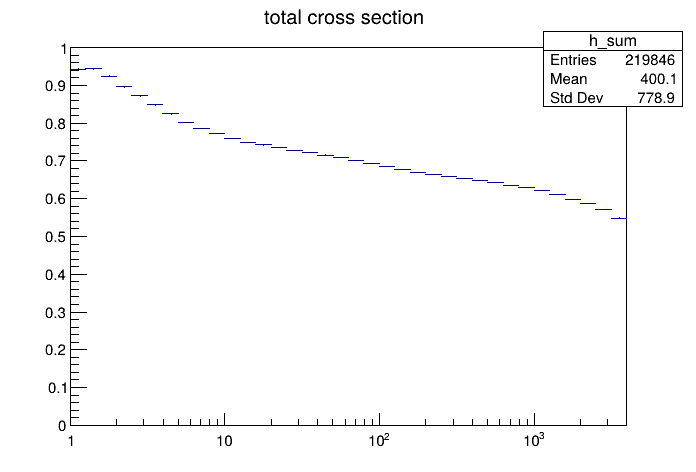

In [29]:
c0 = r.TCanvas()
h_sum.Draw()
h_sum.SetAxisRange(0,1.0,"Y")
c0.SetLogx()
c0.Draw()

In [30]:
h_sum_ccdis = r.TH1D("h_sum_ccdis","ccdis cross section numu",nbinsE,Ebin_borders_c)
for profile in profiles:
    if "dis" in profile.GetName():
        h_sum_ccdis.Add(profile.ProjectionX("h_ccdis_"+profile.GetName()))

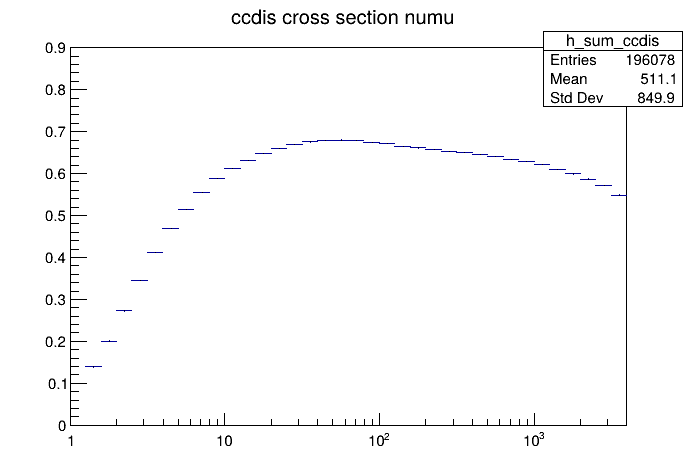

In [31]:
c1 = r.TCanvas()
h_sum_ccdis.Draw()
h_sum_ccdis.SetAxisRange(0,0.9,"Y")
c1.SetLogx()
c1.Draw()

# Now for anti neutrinos

In [32]:
#filter per neutrino type
df_numu_bar = df2.Filter("neu==-14");
#target must be tungsten
df_numu_bar_W = df_numu_bar.Filter("tgt==1000741840");

In [33]:
def selectchannel_bar(cc,inttype,hitnuc,charm,sea = "None",hitqrk = "None", resid = "None"):
 dfint = df_numu_bar_W.Filter(cc+"&&"+inttype+"&&"+hitnuc+"&&"+charm)
 if (inttype=="dis"):
     dfintqrk = dfint.Filter(sea+"&&"+hitqrk)
     return dfintqrk
 if (inttype=="res"):
     dfintqrk = dfint.Filter(resid)
     return dfintqrk
 
 else: 
     return dfint
    

In [34]:
charge = ["cc"]
charms = ["charm","!charm"]
inttypes = ["qel","mec","coh","imd","nuel"]


hitnuclei = ["hitnuc==2212","hitnuc==2112"]

In [35]:
profiles_bar = []
for cc in charge:
    for inttype in inttypes:
        for hitnuc in hitnuclei:
            for charm in charms:
                selectdf = selectchannel_bar(cc, inttype, hitnuc,charm);
                profiles_bar.append(selectdf.Profile1D(("prof_bar"+cc+"_"+inttype+"_"+hitnuc+"_"+charm,"Int Profile",nbinsE,Ebin_borders_c,minxsec,maxxsec),"Ev","xsecN_overE"))
            
    

In [36]:
#ccres need to loop over all resids
resonances = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]

for resid in resonances:
    for hitnuc in hitnuclei:
        for charm in charms:
            selectdf = selectchannel_bar("cc", "res", hitnuc,charm,resid=f"resid=={resid}")
            profiles_bar.append(selectdf.Profile1D(("prof_bar"+cc+"_"+inttype+"_"+hitnuc+"_"+charm+f"_resid_{resid}","Int Profile",nbinsE,Ebin_borders_c,minxsec,maxxsec),"Ev","xsecN_overE"))


In [37]:
#profiles = []
#ccdis need to loop over all quarks
quarks = [-6,-5,-4,-3,-2,-1,1,2,3,4,5,6]
sea_valence = ["!sea","sea"]
charge = ["cc"]
hitnuclei = ["hitnuc==2212","hitnuc==2112"]

for cc in charge:
    for charm in charms:
        for hitnuc in hitnuclei:
            for issea in sea_valence:
                for quark in quarks:
                    selectdf = selectchannel_bar(cc,"dis",hitnuc,charm,issea,f"hitqrk=={quark}")
                    profiles_bar.append(selectdf.Profile1D(("prof_bar"+cc+"_dis_"+hitnuc+"_"+charm+"_"+issea+f"_quark_{quark}","Int Profile",nbinsE,Ebin_borders_c,minxsec,maxxsec),"Ev","xsecN_overE"));

In [38]:
h_sum_bar = r.TH1D("h_sum_bar","total cross section anti neutrino",nbinsE,Ebin_borders_c)
for profile in profiles_bar:
    h_sum_bar.Add(profile.ProjectionX("h_bar"+profile.GetName()))

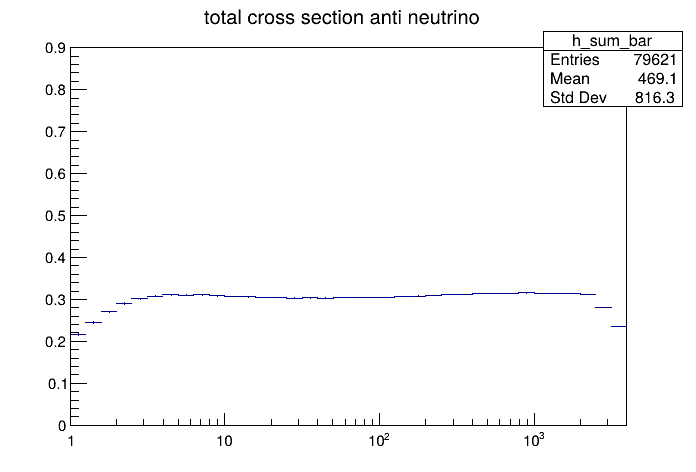

In [39]:
c10 = r.TCanvas()
h_sum_bar.Draw()
h_sum_bar.SetAxisRange(0,0.9,"Y")
c10.SetLogx()
c10.Draw()

In [40]:
h_sum_bar_ccdis = r.TH1D("h_sum_bar_ccdis","ccdis cross section anti numu",nbinsE,Ebin_borders_c)
for profile in profiles_bar:
    if "dis" in profile.GetName():
        h_sum_bar_ccdis.Add(profile.ProjectionX("h_ccdis_bar"+profile.GetName()))

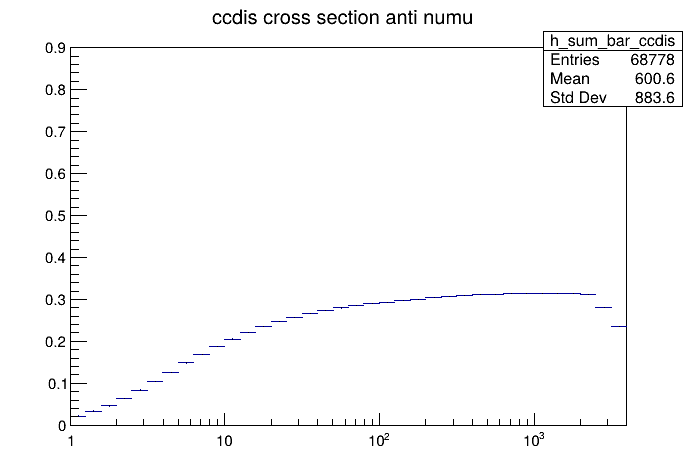

In [41]:
c11 = r.TCanvas()
h_sum_bar_ccdis.Draw()
h_sum_bar_ccdis.SetAxisRange(0,0.9,"Y")
c11.SetLogx()
c11.Draw()

## Including both nu and nu bar

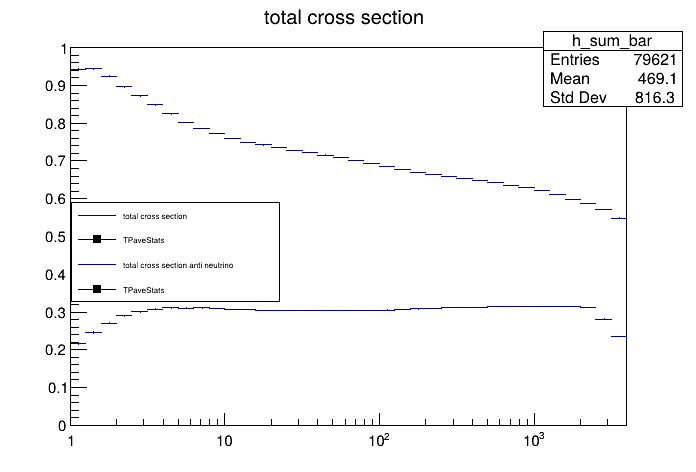

In [42]:
c_comparison = r.TCanvas()
h_sum.Draw()
h_sum.SetAxisRange(0,1.0,"Y")
h_sum_bar.Draw("SAME")
c_comparison.BuildLegend()
c_comparison.SetLogx()
c_comparison.Draw()


In [43]:
#setting errors according to histogram
for i in range(1, hE_CCDIS_numu.GetNbinsX() + 1):
    relerror = hE_CCDIS_numu.GetBinError(i)/hE_CCDIS_numu.GetBinContent(i)
    # Reset error to sqrt(content)
    h_sum_ccdis.SetBinError(i, relerror * h_sum_ccdis.GetBinContent(i))

In [44]:
#setting errors according to histogram
for i in range(1, hE_CCDIS_numu_bar.GetNbinsX() + 1):
    relerror = hE_CCDIS_numu_bar.GetBinError(i)/hE_CCDIS_numu_bar.GetBinContent(i)
    # Reset error to sqrt(content)
    h_sum_bar_ccdis.SetBinError(i, relerror * h_sum_bar_ccdis.GetBinContent(i))

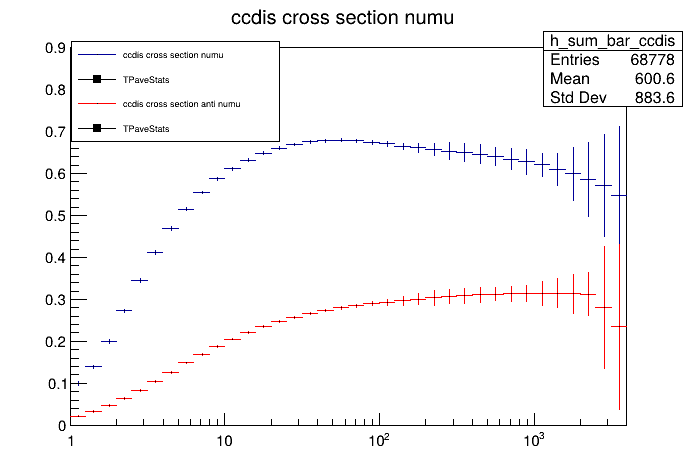

In [45]:
c_comparison_ccdis = r.TCanvas()
h_sum_ccdis.Draw("E")
h_sum_ccdis.SetAxisRange(0,0.9,"Y")
#h_sum_ccdis.SetAxisRange(10,4000.,"X")
h_sum_bar_ccdis.Draw("SAME && E")
h_sum_bar_ccdis.SetLineColor(r.kRed)
c_comparison_ccdis.BuildLegend()
c_comparison_ccdis.SetLogx()
c_comparison_ccdis.Draw()